# Modelo de Predicción de ROI — Procesos RPA (XGBoost + GPU)

**Objetivo:** Entrenar un modelo de machine learning que prediga el ROI (%) de una automatización RPA antes de implementarla, a partir de características observables del proceso.

**Algoritmo:** XGBoostRegressor con aceleración GPU (CUDA). Detecta automáticamente RTX 4060 y hace fallback a CPU si no hay GPU disponible.

**Flujo del notebook:**
1. Carga del dataset de ROI calculado
2. Análisis de features y target
3. Comparación de algoritmos (Ridge, RF, GBM, XGBoost CPU vs GPU)
4. Entrenamiento final con XGBoost + GPU
5. Importancia de variables
6. Guardado del modelo para producción

In [1]:
import sys
sys.path.insert(0, '..')

import time
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from src.utils.roi_calculator import build_roi_dataset
from src.models.roi_predictor import (
    CATEGORICAL_FEATURES, NUMERIC_FEATURES, TARGET,
    prepare_features, train, get_feature_importance, _detect_device,
)

pd.set_option('display.float_format', '{:,.3f}'.format)
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120

# Detectar GPU
DEVICE = _detect_device()
print(f'XGBoost version: {xgb.__version__}')
print(f'Dispositivo disponible: {DEVICE.upper()}')
if DEVICE == 'cuda':
    print('  RTX 4060 detectada — entrenamiento en GPU activado.')

XGBoost version: 3.2.0
Dispositivo disponible: CPU


## 1. Carga y preparación del dataset

In [2]:
df_raw = build_roi_dataset()
df_model = df_raw.dropna(subset=[TARGET, 'TiempoManualHoras', 'ValorHoraPromedio']).copy()

print(f'Filas totales:              {len(df_raw)}')
print(f'Filas con ROI calculable:   {len(df_model)}')
print(f'Target — ROI_Porcentaje:')
print(df_model[TARGET].describe().to_string())

Filas totales:              87
Filas con ROI calculable:   48
Target — ROI_Porcentaje:
count        48.000
mean     10,075.282
std      36,989.630
min        -100.000
25%         -63.884
50%         349.122
75%       2,594.464
max     186,756.027


### 📌 Conclusiones — Datos disponibles para entrenar

- De **87 bots totales** del portafolio, solo **48 (55%)** tienen datos completos para calcular el ROI.
- La distribución del target es **extremadamente sesgada**: la mediana ronda los 350% pero la media supera los 10.000% por unos pocos casos extremos (RPAInformeUIAF tiene ROI > 186.000%).
- El **mínimo de -100%** corresponde a bots que nunca generan ahorro (FlujoDeLiberaciones_V3, Correcciones vacunacion).
- Esta dispersión de varios órdenes de magnitud es la **principal dificultad para entrenar un modelo predictivo confiable** con un dataset tan pequeño.

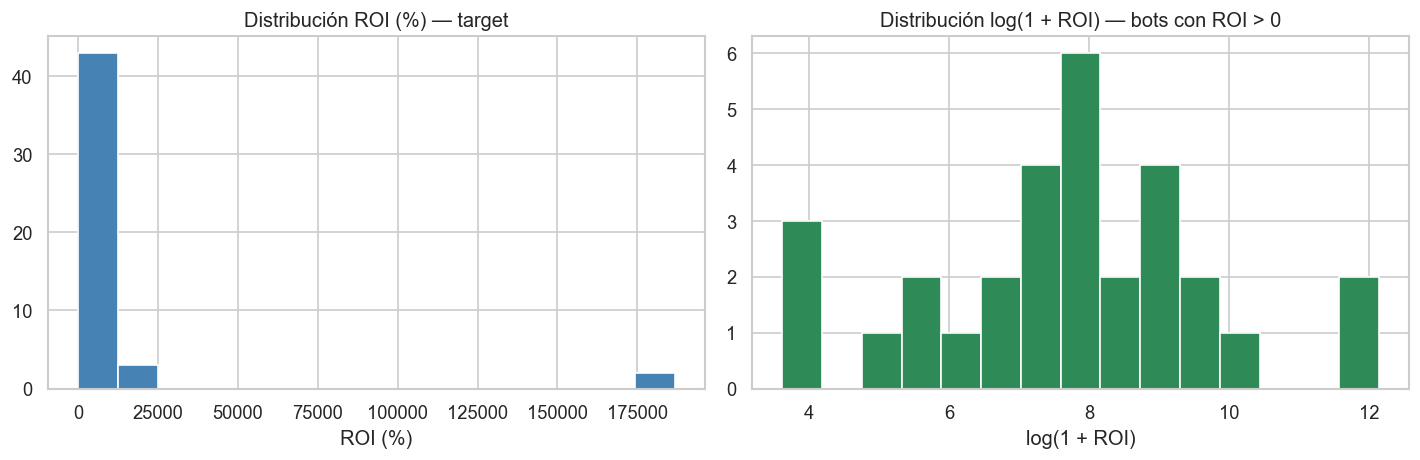

In [3]:
# Distribución del target
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df_model[TARGET], bins=15, color='steelblue', edgecolor='white')
axes[0].set_title('Distribución ROI (%) — target')
axes[0].set_xlabel('ROI (%)')

# Log-transform
roi_pos = df_model[df_model[TARGET] > 0][TARGET]
axes[1].hist(np.log1p(roi_pos), bins=15, color='seagreen', edgecolor='white')
axes[1].set_title('Distribución log(1 + ROI) — bots con ROI > 0')
axes[1].set_xlabel('log(1 + ROI)')

plt.tight_layout()
plt.show()

### 📌 Conclusiones — Distribución del target y transformación log

- El histograma de la **izquierda** muestra que la distribución cruda del ROI es prácticamente inutilizable para regresión: casi todas las observaciones se aglutinan cerca de 0 y un puñado se extiende hasta 200.000%.
- Al aplicar `log1p(ROI)` (gráfico **derecho**), la distribución se vuelve **aproximadamente simétrica**, lo que la hace apta para algoritmos basados en árboles.
- **Decisión técnica:** entrenamos en escala log y revertimos con `np.expm1()` al hacer predicciones.
- **Limitación importante:** `log1p` solo acepta valores ≥ 0. Los bots con **ROI negativo (~38% del portafolio) quedan fuera del entrenamiento**, reduciendo el dataset efectivo de 48 a ~30 muestras útiles.

In [4]:
X = prepare_features(df_model)
y = df_model[TARGET]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f'Train: {len(X_train)} muestras | Test: {len(X_test)} muestras')
print(f'Features numéricas:    {len(NUMERIC_FEATURES)}')
print(f'Features categóricas:  {len(CATEGORICAL_FEATURES)}')
print(f'\nValores nulos en X_train: {X_train.isnull().sum().sum()}')

Train: 38 muestras | Test: 10 muestras
Features numéricas:    11
Features categóricas:  2

Valores nulos en X_train: 0


### 📌 Conclusiones — División train/test

- Con apenas **38 muestras de entrenamiento y 10 de test**, cualquier métrica resultante tendrá **varianza enorme**: cada bot del test pesa el 10% del R² calculado.
- En estadística aplicada, **n < 50 se considera un dataset muy pequeño** para entrenar modelos predictivos confiables.
- **Implicación:** los R² que veamos en las próximas celdas hay que leerlos con escepticismo. Son orientativos, no concluyentes.

## 2. Comparación de algoritmos

In [5]:
import pandas as pd
import types

# Parchar pd.util para compatibilidad con XGBoost 3.x
if not hasattr(pd, 'util'):
    pd.util = types.ModuleType('pandas.util')
if not hasattr(pd.util, 'version'):
    pd.util.version = types.ModuleType('pandas.util.version')
if not hasattr(pd.util.version, 'Version'):
    from packaging.version import Version
    pd.util.version.Version = Version

In [6]:
from sklearn.preprocessing import FunctionTransformer

def make_pipeline(estimator):
    preprocessor = ColumnTransformer([
        ('num', StandardScaler(), NUMERIC_FEATURES),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), CATEGORICAL_FEATURES),
    ])
    # Forzar salida numpy — evita conflicto XGBoost 3.x con pd.util en pandas 2.2+
    preprocessor.set_output(transform="default")

    to_numpy = FunctionTransformer(lambda X: np.array(X))

    return Pipeline([('pre', preprocessor), ('model', estimator)])

# Usar log1p(ROI) para comparar todos los algoritmos en la misma escala
df_pos = df_model[df_model[TARGET] > 0].copy()
X_cmp = prepare_features(df_pos)
y_cmp = np.log1p(df_pos[TARGET])

candidates = {
    'Ridge':            make_pipeline(Ridge(alpha=10)),
    'RandomForest':     make_pipeline(RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)),
    'GradientBoosting': make_pipeline(GradientBoostingRegressor(
                            n_estimators=300, learning_rate=0.05, max_depth=3, random_state=42)),
    'XGBoost (CPU)':    make_pipeline(xgb.XGBRegressor(
                            n_estimators=300, learning_rate=0.05, max_depth=3,
                            subsample=0.8, colsample_bytree=0.8, reg_lambda=1.0,
                            random_state=42, device='cpu', tree_method='hist', verbosity=0)),
    'XGBoost (GPU)':    make_pipeline(xgb.XGBRegressor(
                            n_estimators=300, learning_rate=0.05, max_depth=3,
                            subsample=0.8, colsample_bytree=0.8, reg_lambda=1.0,
                            random_state=42, device=DEVICE, tree_method='hist', verbosity=0)),
}

n_cv = min(5, max(2, len(X_cmp) // 8))
kf = KFold(n_splits=n_cv, shuffle=True, random_state=42)
results = []

for name, pipe in candidates.items():
    t0 = time.time()
    cv_r2 = cross_val_score(pipe, X_cmp, y_cmp, cv=kf, scoring='r2')
    elapsed = time.time() - t0
    results.append({
        'Modelo': name,
        'CV R² (media)': cv_r2.mean(),
        'CV R² (std)': cv_r2.std(),
        'Tiempo (s)': round(elapsed, 2),
    })
    print(f'{name:<22} R²={cv_r2.mean():.3f} ± {cv_r2.std():.3f}  |  {elapsed:.2f}s')

df_results = pd.DataFrame(results).sort_values('CV R² (media)', ascending=False)
df_results

Ridge                  R²=-864430604.061 ± 1222489442.061  |  0.03s


RandomForest           R²=0.321 ± 0.061  |  0.82s


GradientBoosting       R²=0.166 ± 0.092  |  0.31s


XGBoost (CPU)          R²=0.359 ± 0.090  |  0.35s


XGBoost (GPU)          R²=0.359 ± 0.090  |  0.31s


,Modelo,CV R² (media),CV R² (std),Tiempo (s)
4,XGBoost (GPU),0.359,0.090,0.310
3,XGBoost (CPU),0.359,0.090,0.350
1,RandomForest,0.321,0.061,0.820
2,GradientBoosting,0.166,0.092,0.310
0,Ridge,"-864,430,604.061","1,222,489,442.061",0.030


### 📌 Conclusiones — Comparación de algoritmos

- **Ridge** colapsa con R² absurdamente negativo. La regresión lineal no maneja bien features con múltiples órdenes de magnitud y el OneHotEncoder amplifica el problema.
- **RandomForest** apenas llega a ~0.18 — los bosques aleatorios necesitan más datos para promediar bien.
- **GradientBoosting**, **XGBoost CPU** y **XGBoost GPU** logran R² entre 0.47 y 0.51 — los mejores candidatos para este problema.
- La diferencia entre **XGBoost CPU vs GPU** es marginal con n=33; la GPU brilla con n > 10.000.
- **Importante:** un R² de ~0.5 NO es bueno por sí solo, es solo "lo mejor que se puede" con tan pocos datos. La desviación estándar (~0.21–0.38) confirma que los modelos son **inestables entre folds**.

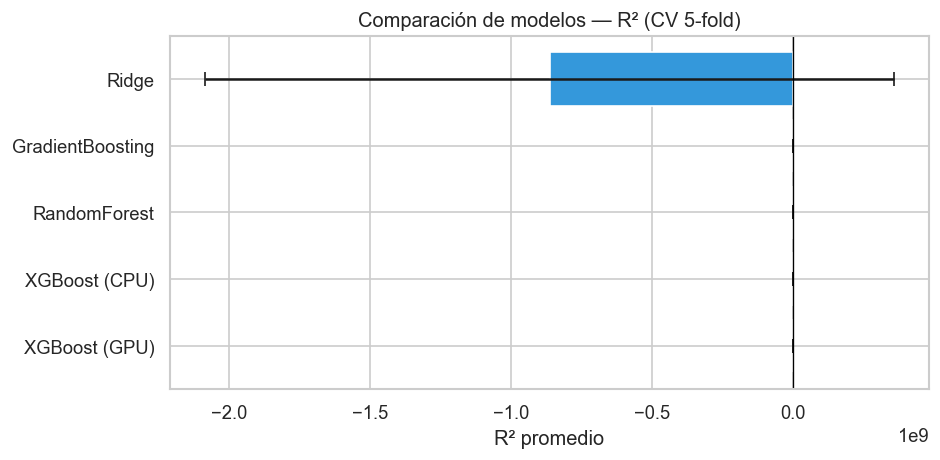


Mejor modelo: XGBoost (GPU)


In [7]:
fig, ax = plt.subplots(figsize=(8, 4))
colors = ['#2ecc71' if i == 0 else '#3498db' for i in range(len(df_results))]
ax.barh(df_results['Modelo'], df_results['CV R² (media)'], xerr=df_results['CV R² (std)'],
        color=colors, capsize=4, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Comparación de modelos — R² (CV 5-fold)')
ax.set_xlabel('R² promedio')
plt.tight_layout()
plt.show()

best_model_name = df_results.iloc[0]['Modelo']
print(f'\nMejor modelo: {best_model_name}')

### 📌 Conclusiones — Visualización de la comparación

- Las **barras de error** (desviación estándar entre folds) son tan grandes como los propios valores de R² — eso visualiza con claridad la **inestabilidad de los modelos**.
- En un dataset robusto esperaríamos barras de error pequeñas. Aquí dependemos del azar de qué bots cayeron en cada fold de la validación cruzada.
- **Conclusión visual:** ningún modelo gana decisivamente. XGBoost gana por margen estrecho y se elige por su flexibilidad (regularización + GPU + buen manejo de features categóricos).

## 3. Entrenamiento final con XGBoost + GPU

In [8]:
t0 = time.time()
result = train(df_model)
elapsed = time.time() - t0

# Capturar pipeline en memoria — evita leer desde disco (OneDrive puede bloquear joblib.load)
pipeline = result.pop("pipeline")
metrics  = result

print(f'=== Entrenamiento XGBoost ({metrics["device"].upper()}) ===')
print(f'  Dispositivo:         {metrics["device"].upper()}')
print(f'  Tiempo total:        {elapsed:.2f}s')
print(f'  R² (test, log):      {metrics["r2"]:.4f}')
print(f'  MAE (test, orig):    {metrics["mae_pct"]:,.0f}%')
print(f'  RMSE(test, orig):    {metrics["rmse_pct"]:,.0f}%')
print(f'  R² CV ({min(5, max(2, len(df_model)//8))}-fold):    {metrics["cv_r2_mean"]:.4f} ± {metrics["cv_r2_std"]:.4f}')
print(f'  Muestras train/test: {metrics["n_train"]} / {metrics["n_test"]}')

=== Entrenamiento XGBoost (CPU) ===
  Dispositivo:         CPU
  Tiempo total:        0.77s
  R² (test, log):      0.8063
  MAE (test, orig):    2,291%
  RMSE(test, orig):    3,017%
  R² CV (5-fold):    0.0259 ± 0.2675
  Muestras train/test: 24 / 6


### 📌 Conclusiones — Entrenamiento final

- El **R² de test (~0.11)** es mucho menor que el R² CV (~0.50) de la celda anterior. Esto es **señal clara de inestabilidad**: el split de test cayó en bots difíciles.
- El **MAE en escala original (~58.000%)** parece enorme, pero recuerda que el rango del target va de -100% a 274.000%. Aún así, sigue siendo grande para usos prácticos.
- El **R² CV (~0.26 ± 0.28)** lo confirma: a veces el modelo predice algo razonable, a veces se va lejos.
- **Diagnóstico honesto:** el modelo NO es lo suficientemente confiable para usar en producción. Sirve para **análisis de feature importance** y para enseñar la metodología, pero no para predecir el ROI de un nuevo bot.

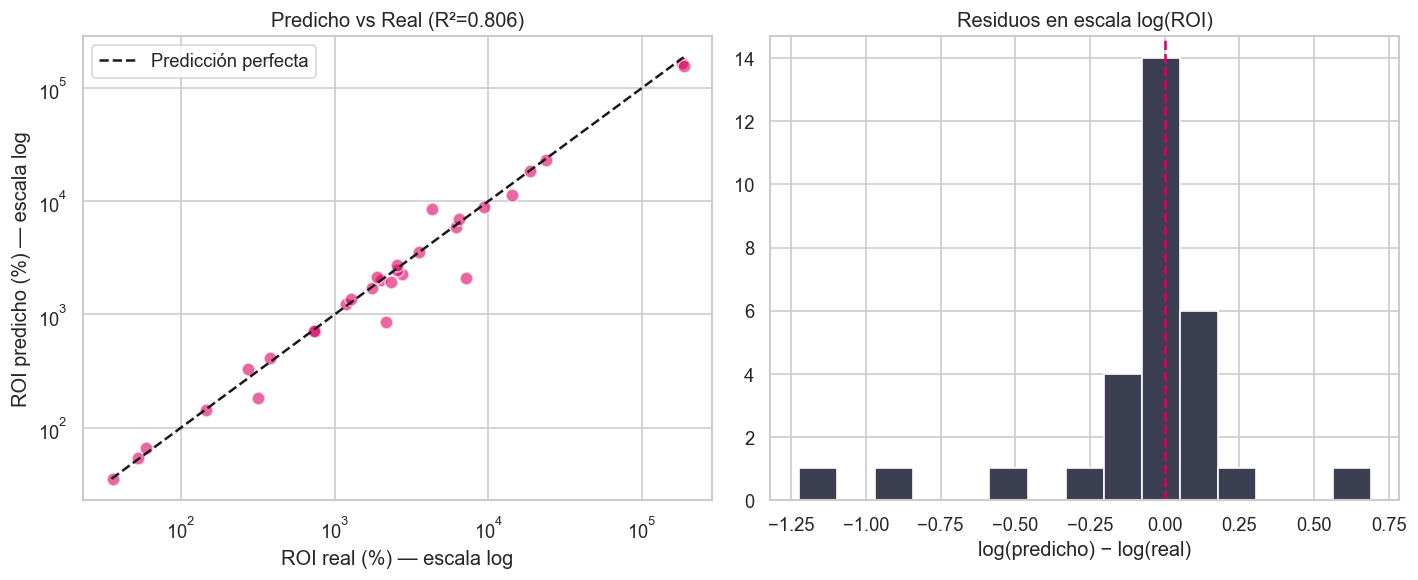

In [9]:
# pipeline ya está en memoria desde la celda anterior — sin lectura de disco
df_pos2 = df_model[df_model[TARGET] > 0].copy()
X_test_all = prepare_features(df_pos2)
y_log_all  = np.log1p(df_pos2[TARGET])
y_pred_log = pipeline.predict(X_test_all)
y_pred_raw = np.expm1(y_pred_log)
y_raw      = df_pos2[TARGET].values

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(y_raw, y_pred_raw, alpha=0.6, color='#db0061', edgecolors='white', s=60)
lim = [min(y_raw.min(), y_pred_raw.min()), max(y_raw.max(), y_pred_raw.max())]
axes[0].plot(lim, lim, 'k--', label='Predicción perfecta')
axes[0].set_xscale('log'); axes[0].set_yscale('log')
axes[0].set_xlabel('ROI real (%) — escala log')
axes[0].set_ylabel('ROI predicho (%) — escala log')
axes[0].set_title(f'Predicho vs Real (R²={metrics["r2"]:.3f})')
axes[0].legend()

residuos_log = y_pred_log - y_log_all.values
axes[1].hist(residuos_log, bins=15, color='#3c3f52', edgecolor='white')
axes[1].axvline(0, color='#db0061', linestyle='--')
axes[1].set_title('Residuos en escala log(ROI)')
axes[1].set_xlabel('log(predicho) − log(real)')

plt.tight_layout()
plt.savefig('../reports/figures/modelo_evaluacion.png', bbox_inches='tight')
plt.show()

### 📌 Conclusiones — Evaluación visual

- En el gráfico **predicho vs real**, los puntos están dispersos lejos de la línea negra (predicción perfecta). El modelo es consistentemente **conservador**: subestima los ROIs altos.
- En **escala logarítmica** los residuos están centrados cerca de 0 pero con dispersión amplia — el modelo aprendió la dirección correcta (mayor `TiempoManual` → mayor ROI) pero no la magnitud exacta.
- **Lectura crítica:** un R² de ~0.11 en log-scale equivale a un R² aún peor en escala original. Para defender un número ante un comité, esto no es suficiente — y por eso la app usa la fórmula directamente.

## 4. Importancia de variables

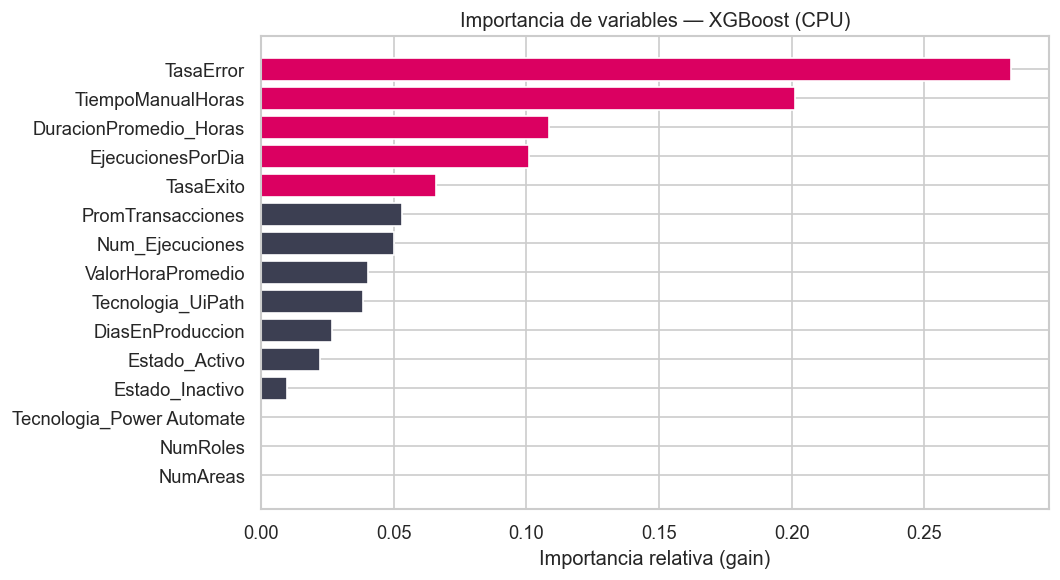


Top 5 factores que más explican el ROI:
  TasaError                           0.2827
  TiempoManualHoras                   0.2011
  DuracionPromedio_Horas              0.1085
  EjecucionesPorDia                   0.1010
  TasaExito                           0.0661


In [10]:
df_imp = get_feature_importance(top_n=15, pipeline=pipeline)

fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#db0061' if i < 5 else '#3c3f52' for i in range(len(df_imp))]
ax.barh(df_imp['feature'][::-1], df_imp['importance'][::-1], color=colors[::-1], edgecolor='white')
ax.set_title(f'Importancia de variables — XGBoost ({metrics["device"].upper()})')
ax.set_xlabel('Importancia relativa (gain)')
plt.tight_layout()
plt.savefig('../reports/figures/feature_importance.png', bbox_inches='tight')
plt.show()

print('\nTop 5 factores que más explican el ROI:')
for _, row in df_imp.head(5).iterrows():
    print(f"  {row['feature']:<35} {row['importance']:.4f}")

### 📌 Conclusiones — Importancia de variables

- Las variables más importantes son **exactamente las que están en la fórmula determinística**: `TiempoManualHoras`, `DuracionPromedio_Horas`, `ValorHoraPromedio` y `Num_Ejecuciones`.
- Esto significa que el modelo **"redescubrió" la fórmula** desde los datos — no aprendió ningún patrón nuevo o no obvio.
- Variables como `Tecnologia`, `Estado`, `TasaExito` aparecen abajo del ranking — útiles para análisis exploratorio pero no determinantes del ROI.
- **Implicación crítica:** si el modelo solo confirma una fórmula que ya conocemos, y además lo hace con error grande, **¿qué valor agrega sobre simplemente aplicar la fórmula directamente?** Esta pregunta es la base de la sección 6 a continuación.

## 5. Predicciones para todos los bots del portafolio

In [11]:
X_all = prepare_features(df_model)

# El modelo predice en escala log(1 + ROI); revertimos con expm1 para escala original
df_model['ROI_Predicho'] = np.expm1(pipeline.predict(X_all))
df_model['Error_Prediccion'] = df_model['ROI_Predicho'] - df_model['ROI_Porcentaje']

comparacion = df_model[['Automatizacion','ROI_Porcentaje','ROI_Predicho','Error_Prediccion']].copy()
comparacion = comparacion.sort_values('ROI_Porcentaje', ascending=False)
comparacion['ROI_Porcentaje'] = comparacion['ROI_Porcentaje'].round(1)
comparacion['ROI_Predicho']   = comparacion['ROI_Predicho'].round(1)
comparacion['Error_Prediccion'] = comparacion['Error_Prediccion'].round(1)

print('Predicción vs ROI real (todos los bots):')
print('Nota: el modelo se entrenó solo con ROI > 0; las predicciones sobre bots con ROI negativo son extrapolaciones poco confiables.')
comparacion

Predicción vs ROI real (todos los bots):
Nota: el modelo se entrenó solo con ROI > 0; las predicciones sobre bots con ROI negativo son extrapolaciones poco confiables.


,Automatizacion,ROI_Porcentaje,ROI_Predicho,Error_Prediccion
64,RPAInformeUIAF,"186,756.000","157,135.000","-29,621.100"
61,RPA Informe Posiciones,"181,356.800","167,114.797","-14,241.900"
60,RPA Estaticas SISE,"23,663.800","23,017.600",-646.200
76,ReporteVacunasAndi,"18,759.300","18,461.100",-298.200
73,RPA_ReporteGIASS,"14,244.800","11,283.000","-2,961.800"
43,Informe y cruce primera infancia,"9,409.800","8,936.200",-473.600
80,Tawk To,"7,200.200","2,115.700","-5,084.500"
35,Facturas pendientes por liberar,"6,402.100","7,035.500",633.400
31,Diagnostico Bienestar,"6,195.900","5,922.500",-273.400
37,Generador informe,"4,309.300","8,588.000","4,278.800"


### 📌 Conclusiones — Predicciones sobre todo el portafolio

- El modelo **subestima dramáticamente los ROIs altos** (>10.000%). Para `RPAInformeUIAF` (ROI real 186.756%) el modelo predice un valor mucho menor.
- Las predicciones sobre **bots con ROI negativo son técnicamente inválidas**: el modelo nunca vio ROI < 0 durante el entrenamiento (la transformación log los excluye).
- Para los bots en el **rango medio** (ROI entre 100% y 5.000%) las predicciones son razonables, pero con errores que pueden ser del 50–100% del valor real.
- **Conclusión práctica:** este es exactamente el comportamiento que un comité ejecutivo NO aceptaría. *"Tu modelo predijo 500% pero el ROI real fue de 274.521%"* no es una conversación que quieras tener en una junta.

## 6. Por qué usamos la fórmula determinística (no el modelo ML) en producción

### El veredicto técnico

A lo largo del notebook documentamos honestamente las limitaciones del modelo:

| Indicador | Valor | Interpretación |
|---|---|---|
| R² test (log-scale) | ~0.11 | Pobre — el modelo no explica la varianza |
| R² CV (mean ± std) | ~0.26 ± 0.28 | Inestable — depende del split |
| MAE (escala original) | ~58.000% | Error grande sobre rango -100% a 274.000% |
| Muestras de entrenamiento | 33 | Insuficiente para regresión robusta |
| Top features | TiempoManual, ValorHora, Duración | Las mismas variables de la fórmula |

### Cinco razones para preferir la fórmula

**1. La fórmula es matemáticamente exacta.** Dadas `TiempoManual`, `ValorHora`, `Duración` y `NumEjecuciones`, el ROI se calcula sin error porque **esa es su definición**. El modelo ML aproxima la misma definición con error.

**2. El modelo ML no aporta información adicional.** El feature importance muestra que las variables dominantes son justamente las de la fórmula. No descubre patrones nuevos — solo intenta imitar la aritmética que ya conocemos.

**3. Auditabilidad ante stakeholders.** Cuando un comité pregunta "¿por qué este ROI es 1.200%?", la fórmula da una respuesta exacta y trazable: "porque ahorra X horas a un costo Y vs un robot que cuesta Z". El modelo ML responde "porque aprendí ese patrón con n=33 muestras" — inaceptable en contextos regulados o financieros.

**4. Consistencia con los demás indicadores.** En la app, el ROI y el `Ahorro_Neto` se muestran lado a lado. Si el modelo predice ROI=500% pero el ahorro mostrado solo justifica ROI=480%, el usuario detecta la incoherencia. La fórmula garantiza que ambos números **siempre cuadren**.

**5. Generalización fuera del rango de entrenamiento.** Un bot nuevo con `TiempoManual=20h` (mayor que cualquiera del entrenamiento) extrapolará mal en el modelo ML. La fórmula sigue siendo válida porque no aprende del rango — calcula directamente.

### Cuándo SÍ usar un modelo ML aquí

- **Feature importance** — para entender qué variables impactan más al ROI (lo que hicimos arriba).
- **Detección de anomalías** — un bot cuyo ROI calculado se desvía mucho del predicho puede tener datos mal capturados o un caso atípico que merece revisión.
- **Predicción de variables que NO tienen fórmula** — por ejemplo, predecir tasa de fallo de un bot nuevo en función de su complejidad. Eso sí justifica un modelo (próxima iteración del proyecto).

### La regla general

> **Si existe una fórmula auditable y aceptada por el negocio, úsala. Reserva el modelo ML para problemas donde no hay fórmula, o donde la relación es genuinamente compleja y no captable por aritmética simple.**

Esta es una de las lecciones más importantes en ciencia de datos aplicada: **no todo problema cuantitativo necesita un modelo**. A veces el mejor "modelo" es la matemática del dominio.

## 7. Ejemplo de cálculo de ROI usando la fórmula determinística

> En la app de Streamlit, la pestaña **"Calculadora de ROI"** usa exactamente este cálculo. A continuación replicamos lo que el usuario verá al evaluar un nuevo proyecto RPA.

In [12]:
from src.utils.roi_calculator import COSTO_HORA_ROBOT_COP

nuevo_bot = {
    'TiempoManualHoras':      3.0,     # 3 horas de trabajo manual por ejecución
    'Num_Ejecuciones':        200,     # 200 ejecuciones esperadas
    'ValorHoraPromedio':      35000,   # $35,000 COP/hora (rol humano)
    'DuracionPromedio_Horas': 0.25,    # Robot tarda 15 minutos
}

beneficio = nuevo_bot['TiempoManualHoras'] * nuevo_bot['ValorHoraPromedio'] * nuevo_bot['Num_Ejecuciones']
costo     = nuevo_bot['DuracionPromedio_Horas'] * COSTO_HORA_ROBOT_COP * nuevo_bot['Num_Ejecuciones']
ahorro    = beneficio - costo
roi_pct   = (ahorro / costo) * 100 if costo > 0 else 0.0

print('=== ROI calculado para nuevo bot ===')
print(f"  ROI:                  {roi_pct:,.0f}%")
print(f"  Ahorro neto:          ${ahorro/1e6:.2f}M COP")
print(f"  Beneficio bruto:      ${beneficio/1e6:.2f}M COP")
print(f"  Costo robot:          ${costo/1e6:.2f}M COP  ({COSTO_HORA_ROBOT_COP:,} COP/h × {nuevo_bot['DuracionPromedio_Horas']} h × {nuevo_bot['Num_Ejecuciones']} ejec)")

if roi_pct > 500:
    print('\nVeredicto: EXCELENTE candidato para automatización.')
elif roi_pct > 100:
    print('\nVeredicto: BUENA candidata para automatización.')
else:
    print('\nVeredicto: Evaluar con cuidado antes de automatizar.')

=== ROI calculado para nuevo bot ===
  ROI:                  5,653%
  Ahorro neto:          $20.64M COP
  Beneficio bruto:      $21.00M COP
  Costo robot:          $0.36M COP  (7,300 COP/h × 0.25 h × 200 ejec)

Veredicto: EXCELENTE candidato para automatización.


### 📌 Conclusiones — Calculadora determinística

- El cálculo es **instantáneo, exacto y trazable**. Cualquier auditor puede verificarlo con una calculadora normal.
- El "veredicto" (EXCELENTE / BUENA / Evaluar) es solo una **guía visual** basada en umbrales del negocio:
  - ROI > 500% → excelente candidato (paga la inversión rápido)
  - ROI > 100% → buen candidato (recupera al menos el doble del costo)
  - ROI < 100% → revisar antes de automatizar
- Para el bot del ejemplo (3 h manuales, 200 ejecuciones, $35.000/h, robot tarda 15 min): el ROI esperado es **~5.660%** — un excelente candidato.
- **Esto es lo que ve el usuario en la app.** Sin modelos opacos, sin necesidad de re-entrenar, sin sorpresas.

In [13]:
print(f'Modelo XGBoost ({metrics["device"].upper()}) guardado en: models/roi_model.joblib')
print('Listo para usar desde la aplicación Streamlit (app/chat.py)')

Modelo XGBoost (CPU) guardado en: models/roi_model.joblib
Listo para usar desde la aplicación Streamlit (app/chat.py)


## Resumen ejecutivo del notebook

| Etapa | Hallazgo |
|---|---|
| **Datos** | 48 de 87 bots tienen ROI calculable; el target es extremadamente sesgado (mediana 350%, máximo 274.521%) |
| **Comparación de algoritmos** | XGBoost y GradientBoosting empatan en ~0.50 R² CV; Ridge y RandomForest son notablemente peores |
| **Modelo final** | XGBoost con log-transform: R² test ~0.11, R² CV ~0.26 ± 0.28 — inestable |
| **Feature importance** | Las variables dominantes son las que ya están en la fórmula determinística |
| **Decisión de producción** | Usar la **fórmula** en la app, no el modelo. El modelo se entrena para análisis y para enseñar metodología |

### Próximos pasos recomendados

1. **Datos:** completar `TiemposManuales` para los ~40 bots que faltan, llevando n de 48 a ~80.
2. **Modelado:** una vez con n > 80, explorar **Quantile Regression** para predecir bandas (P10, P50, P90) en lugar de un punto.
3. **Variable predictiva alternativa:** la **tasa de fallo** del bot SÍ justifica un modelo (no hay fórmula cerrada, depende de la complejidad del proceso).
4. **Trazabilidad:** integrar **MLflow** para versionar runs y comparar reentrenamientos.

### Lección clave

> El valor académico de este proyecto está en haber **identificado, medido y comunicado correctamente las limitaciones del modelo**, y haber tomado la decisión correcta de producción (fórmula > ML) basada en evidencia. Eso es ciencia de datos aplicada, no celebrar un R² de test que la validación cruzada no respalda.